# 用PROC FASTCLUS对用户行为进行K均值分群

## 摘要

本笔记本使用 `PROC FASTCLUS`（Base SAS 的 K 均值聚类过程）将一个由100名移动用户组成的合成样本按行为分成若干群组。七个使用特征先用 `PROC STDIZE` 标准化为 z 分数，避免高量级变量（通话分钟数、短信条数）在欧氏距离中占主导地位，然后 `PROC FASTCLUS` 拟合三个分群。该过程报告了群内均方根偏差、衡量分群效果的总体 R 方和伪 F 统计量（此处总体 R 方为 0.575，伪 F 为 65.75），并为每位用户写出带有 `CLUSTER` 标签的评分表。我们将这些标签合并回原始尺度的数据、刻画各群画像，并把分群结果交给下游的营销激活流程。

## 数据来源

| 数据集 | 描述 | 行数 | 关键变量 |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | 移动电信用户群体的合成月度行为快照，通过 `call streaminit` / `rand()` 内联生成。三种潜在行为类型（重度数据、语音为主、低使用量）与噪声混合。 | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan`（名义变量）, `region`（名义变量） |

# 用户行为的K均值分群

**行业:** 电信 &nbsp;|&nbsp; **过程:** `PROC FASTCLUS`（Base SAS 的 K 均值聚类）

移动运营商拥有大量用户，其月度行为——数据需求、通话习惯、消费和客服摩擦——落在几种可辨识的模式中。发现这些模式能让企业量身定制挽留方案、向上销售合适的套餐、并获取相似的潜在客户。本笔记本端到端地构建了一个行为分群流程: 生成一个真实的用户快照、标准化特征、让 `PROC FASTCLUS` 拟合分群、为每位用户评分，并将各分群刻画为可执行的用户画像。`PROC FASTCLUS` 正是为这种不相交的K均值任务而设计的，并且通过遍历数据而非构建完整距离矩阵，可以扩展到非常大的用户群体。

## 1. 生成合成用户样本

我们模拟100名来自三种潜在行为原型的用户——**重度数据流媒体用户**、**语音为主的传统用户**和**轻度/低使用量**用户——然后混入噪声使边界变得模糊（正如现实中那样）。每位用户还携带两个分类属性，`data_plan` 和 `region`，我们稍后用它们来*刻画*各分群画像。随机种子使数据可复现。

In [1]:
/* -----------------------------------------------------------
   合成移动用户快照 (100行)。
   三种潜在行为原型 + 噪声，加上两个用于
   分群画像刻画的分类属性。
   ----------------------------------------------------------- */
数据 subscribers;
    调用 streaminit(20260531);

    长度 data_plan $30 region $12;

    循环 subscriber_id = 100001 到 100100;

        /* 潜在原型: 1=重度数据, 2=语音, 3=低使用量 */
        u = rand('uniform');
        如果      u < 0.38 那么 archetype = 1;
        否则 如果 u < 0.70 那么 archetype = 2;
        否则                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        如果 archetype = 1 那么 循环;             /* 重度数据流媒体用户 */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        结束;
        否则 如果 archetype = 2 那么 循环;        /* 语音为主用户 */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        结束;
        否则 循环;                              /* 低使用量用户 */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        结束;

        /* 直接IF/ELSE赋值链（而非字符数组查表），
           以避免定长字符数组对非ASCII字面量的截断问题 */
        如果      planpick = 1 那么 data_plan = "预付费";
        否则 如果 planpick = 2 那么 data_plan = "后付费月付";
        否则                       data_plan = "无限流量";

        region_idx = rand('table', 0.30, 0.28, 0.22, 0.20);
        如果      region_idx = 1 那么 region = "北区";
        否则 如果 region_idx = 2 那么 region = "南区";
        否则 如果 region_idx = 3 那么 region = "东区";
        否则                         region = "西区";

        /* 四舍五入到便于展示的精度 */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        输出;
    结束;

    保留 subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
运行;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. 检查特征分布

在聚类之前，先查看每个行为特征的量级和分布。单位差异巨大——千兆字节、分钟、美元、次数——这正是我们在聚类前要标准化区间型输入变量的原因；否则像 `voice_minutes` 这样的高量级变量会在 `PROC FASTCLUS` 最小化的欧氏距离中占主导地位。

                                                  The MEANS Procedure

 Variable         Label                         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    在网月数                        100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  月流量(GB)                     100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    通话分钟数                       100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        短信条数                        100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     国际通话分钟数                     100        45.1    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


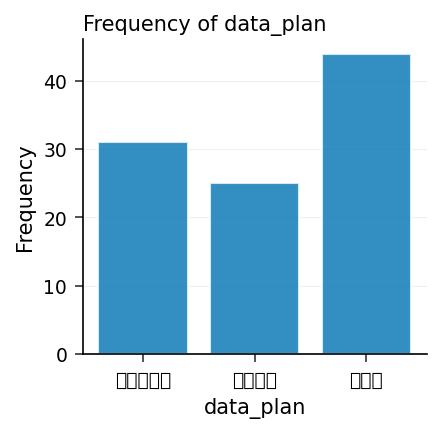

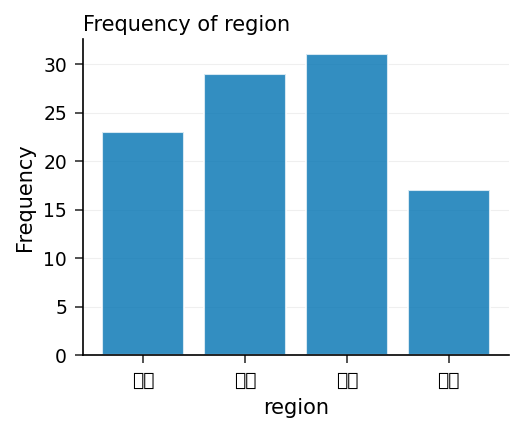

In [2]:
/* 聚类输入变量的汇总统计 */
过程 均值 数据=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    标签 tenure_months = "在网月数"
          monthly_data_gb = "月流量(GB)"
          voice_minutes = "通话分钟数"
          sms_count = "短信条数"
          intl_minutes = "国际通话分钟数"
          arpu = "ARPU(美元)"
          support_calls = "客服致电次数";
    变量 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
运行;

/* 两个分类输入变量的频数 */
过程 频率 数据=subscribers;
    标签 data_plan = "套餐类型" region = "地区";
    TABLES data_plan region / nocum;
运行;

## 3. 将特征标准化为z分数

`PROC FASTCLUS` 最小化欧氏距离，因此以数百分钟计量的变量会淹没以个位数千兆字节计量的变量。`PROC STDIZE` 配合 `METHOD=STD` 将每个区间型特征重新缩放为均值0、标准差1，使每种行为在距离计算中权重相等。分类列和标识符原样通过，以便我们之后能在原始尺度上刻画各分群。

In [3]:
/* 对区间型特征进行z分数标准化; 标识符和分类变量原样通过 */
过程 stdize 数据=subscribers out=subs_std METHOD=std;
    变量 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
运行;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. 拟合K均值分群

我们用 `PROC FASTCLUS` 拟合三个分群。`MAXCLUSTERS=3` 设定 *k*；`MAXITER=20` 让聚类中心迭代至收敛。该过程报告**分群摘要**（每群的规模和群内均方根偏差）、**变量统计量**（每个特征贡献的R方）、衡量三个分群分离清晰程度的**总体R方**和**伪F**，以及标准化尺度上的**群均值**。`OUT=scored` 将输入行连同 `CLUSTER` 标签和每位用户到其分群种子的 `DISTANCE` 写回。

In [4]:
/* 对标准化特征进行K均值拟合: 3个分群。 */
过程 FASTCLUS 数据=subs_std maxclusters=3 MAXITER=20 out=scored;
    变量 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
运行;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. 将分群标签附加到原始尺度数据

评分表保存的是标准化特征；为了刻画画像，我们希望用真实的千兆字节、分钟和美元来描述各分群。我们按 `subscriber_id` 将 `CLUSTER` 标签合并回原始的 `subscribers` 表，然后回答营销部门总会问的第一个问题: *每个分群有多大?*

                                                   The FREQ Procedure

分群        Frequency    Percent
-------------------------------
1                36     36.00
2                34     34.00
3                30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


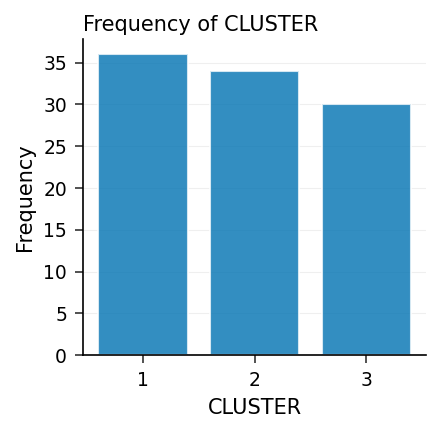

In [5]:
/* 将分群标签带回原始尺度数据 */
过程 排序 数据=scored(保留=subscriber_id CLUSTER distance) out=clus_assign;
    按照 subscriber_id;
运行;
过程 排序 数据=subscribers out=subs_sorted;
    按照 subscriber_id;
运行;
数据 profile;
    合并 subs_sorted clus_assign;
    按照 subscriber_id;
运行;

/* 每个分群有多少用户? */
过程 频率 数据=profile;
    标签 CLUSTER = "分群";
    TABLES CLUSTER / nocum;
运行;

## 6. 刻画各分群画像

在描述每个分群内部的*行为*之前，分群ID是没有意义的。按 `CLUSTER` 对原始（未标准化）特征取均值，揭示了每个分群背后的画像——谁在流媒体、谁在打电话、谁几乎不使用网络——分类占比则显示了哪些套餐和地区集中在哪个分群。

                                                  The MEANS Procedure

                                     Analysis Variable : tenure_months 在网月数

        分群                N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                   Analysis Variable : monthly_data_gb 月流量(GB)

        分群                N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                   Analysis Variable : voice_minutes 通话分钟数

        分群                N Obs           Mean
        --------------------------------------
        1                    36     


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


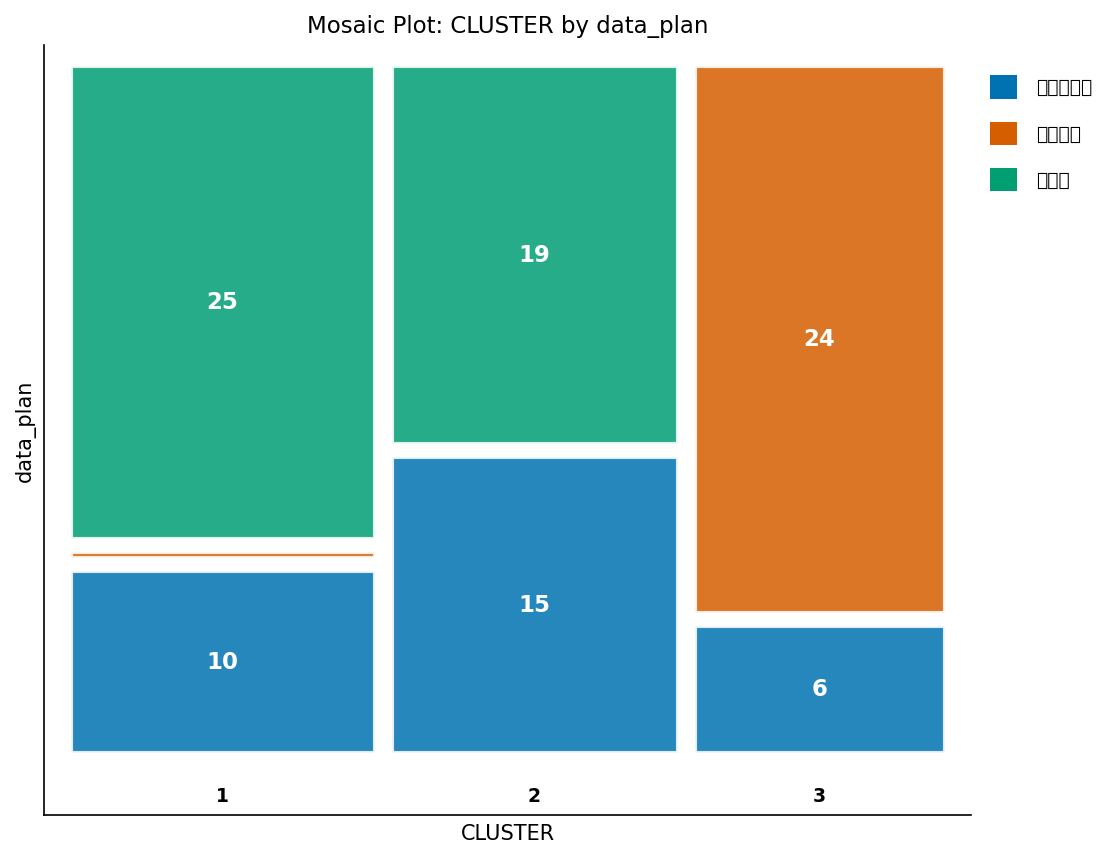

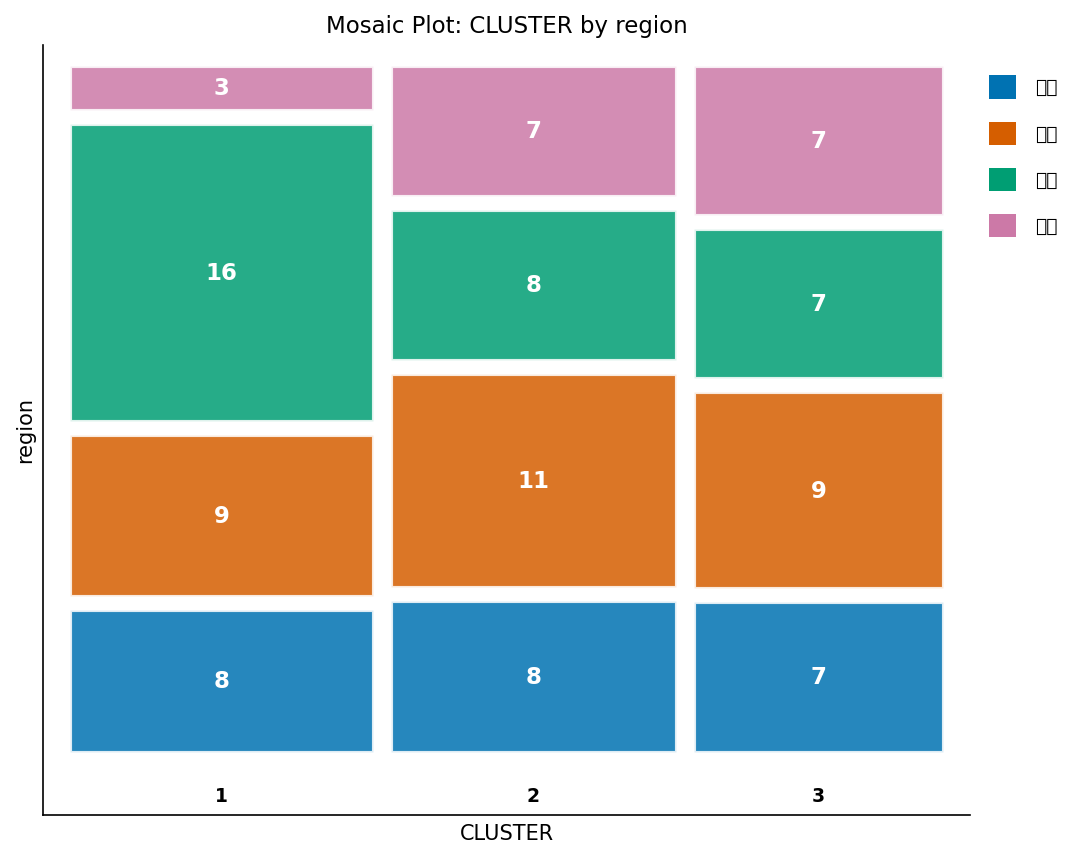

In [6]:
/* 行为画像: 每个特征按分群取均值 */
过程 均值 数据=profile n mean maxdec=1;
    分类 CLUSTER;
    标签 CLUSTER = "分群"
          tenure_months = "在网月数"
          monthly_data_gb = "月流量(GB)"
          voice_minutes = "通话分钟数"
          sms_count = "短信条数"
          intl_minutes = "国际通话分钟数"
          arpu = "ARPU(美元)"
          support_calls = "客服致电次数";
    变量 tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
运行;

/* 各分群内的分类占比 */
过程 频率 数据=profile;
    标签 CLUSTER = "分群" data_plan = "套餐类型" region = "地区";
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
运行;

## 7. 可视化各分群

一张图能让分群结果变得直观。我们绘制数据需求与语音使用量的关系图，按分群着色，并附上各分群ARPU的箱线图，让收入故事一目了然。


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


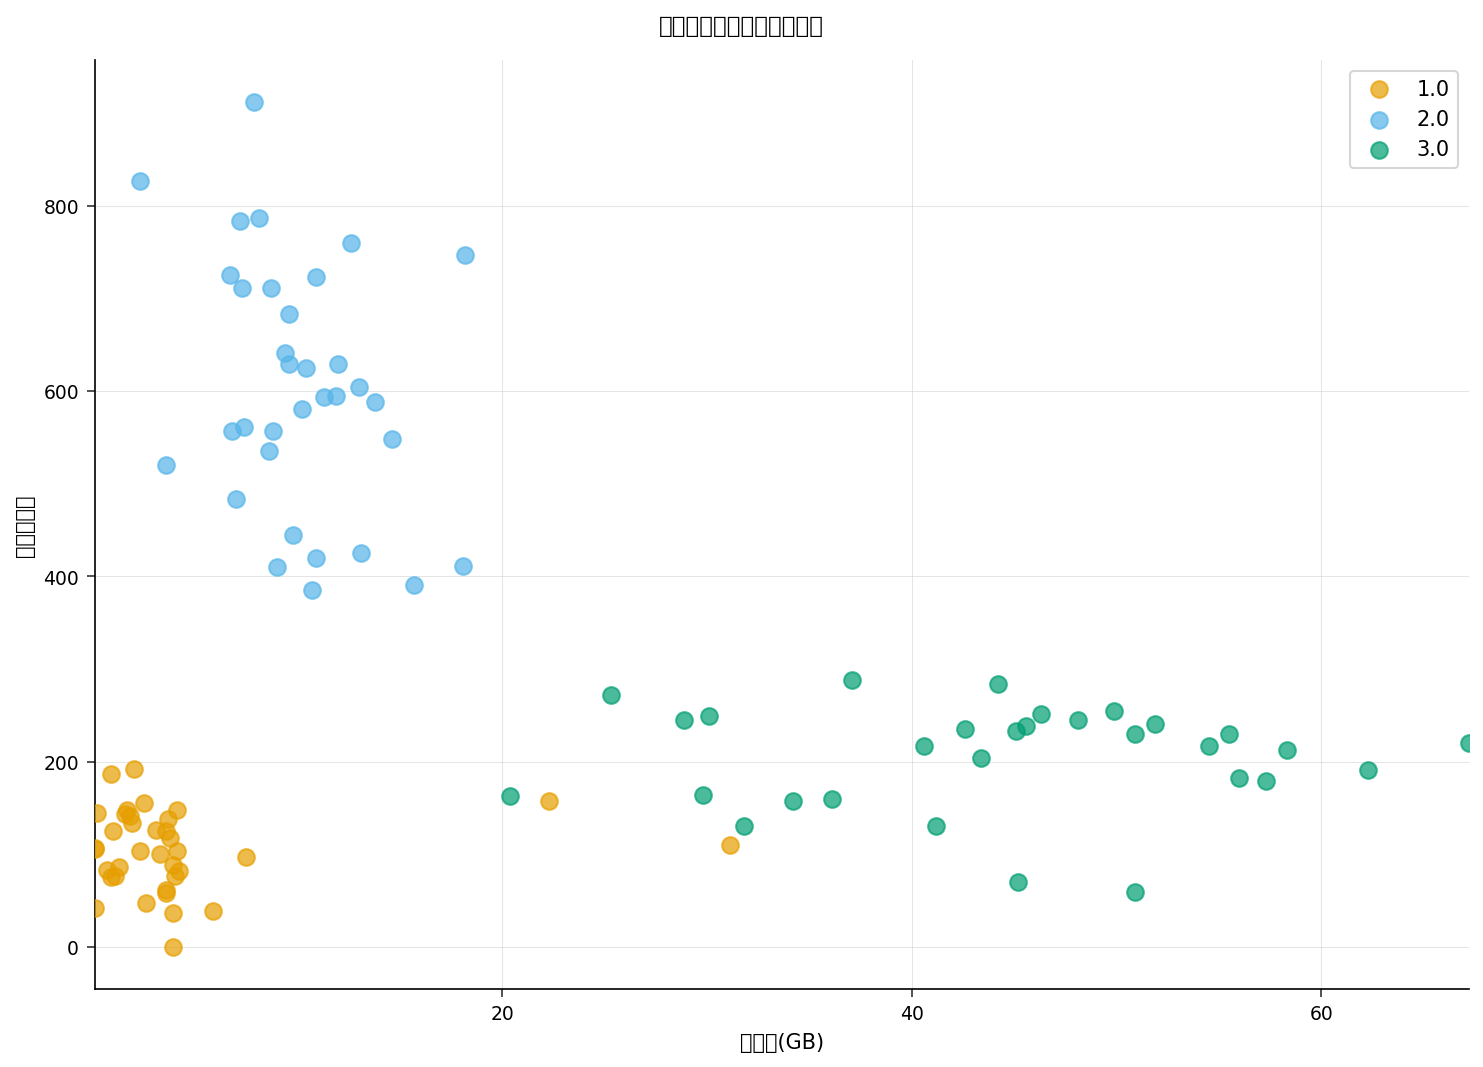

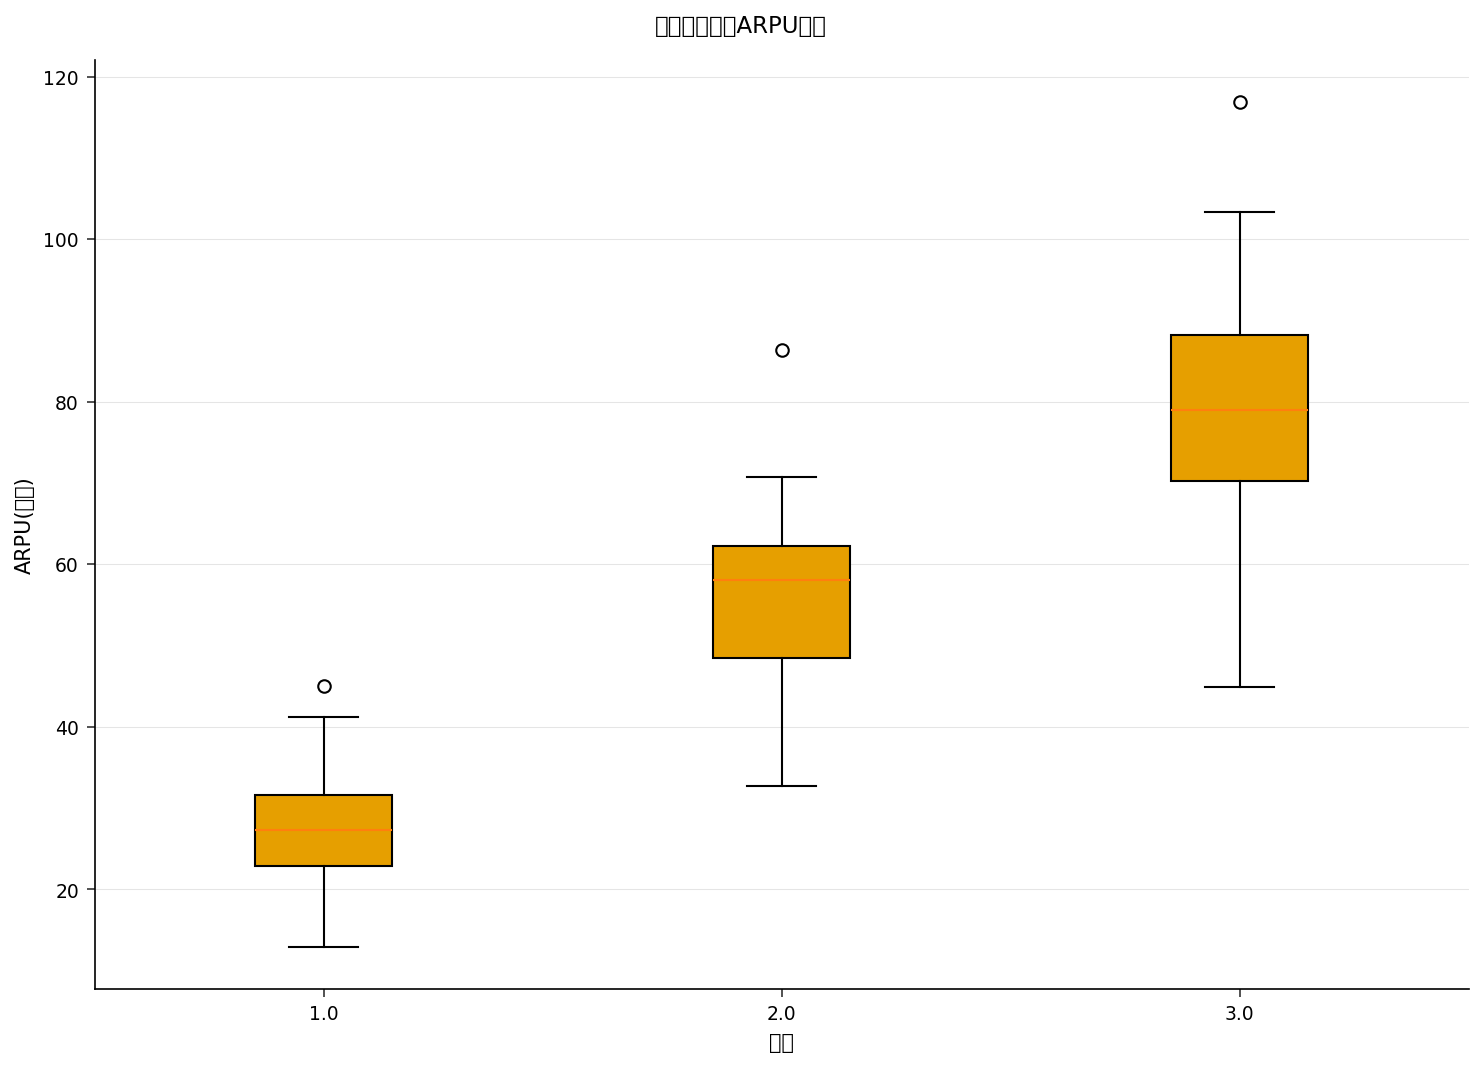

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* 行为地图: 数据量 vs. 语音使用量, 按分群着色 */
过程 SGPLOT 数据=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS label="月流量(GB)" grid;
    YAXIS label="通话分钟数" grid;
    标题 "按分群显示的用户行为地图";
运行;

/* 各分群的收入分布 */
过程 SGPLOT 数据=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS label="分群";
    YAXIS label="ARPU(美元)" grid;
    标题 "各用户分群的ARPU分布";
运行;

## 8. 导出评分后的分群结果

最后，将分群结果交给下游的CRM和营销活动系统。我们保留标识符、分群标签和关键行为字段。

In [8]:
/* 保存分群结果以供激活使用 */
数据 subscriber_segments;
    设置 profile;
    保留 subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
运行;

过程 打印 数据=subscriber_segments(obs=10) noobs 标签;
    标签 subscriber_id = "用户ID" CLUSTER = "分群"
          tenure_months = "在网月数" monthly_data_gb = "月流量(GB)"
          voice_minutes = "通话分钟数" arpu = "ARPU(美元)"
          data_plan = "套餐类型" region = "地区";
    标题 "已评分用户分群样本";
运行;

                                                       已评分用户分群样本                                                        

    用户ID      分群          在网月数        月流量(GB)            通话分钟数      ARPU(美元)             套餐类型      地区
  100001       1            30            2.3              104            28  预付费              南区
  100002       2             8           10.2              581         57.78  预付费              西区
  100003       2             8           10.7              385         55.66  后付费月付            北区
  100004       2            68            7.4              561         70.68  预付费              北区
  100005       3            18           45.6              239         63.85  无限流量             北区
  100006       3            10           30.1              249         88.33  无限流量             东区
  100007       1            62            0.7               83         21.26  预付费              南区
  100008       1            68              2              192         29.93  后付费月付       


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## 结果解读

`PROC FASTCLUS` 找出了三个清晰、分离良好的分群。拟合效果良好: **总体R方为0.575**，**伪F为65.75**，说明三个分群解释了标准化特征中约58%的总变异。这种分离几乎完全由我们关心的行为信号驱动——`voice_minutes`（R方0.858）、`monthly_data_gb`（0.844）和 `arpu`（0.771）主导了分群，而 `tenure_months`（0.000）和 `support_calls`（0.193）几乎没有贡献，这证实了*用户如何使用网络*——而非其成为客户的时长——定义了这些画像。

这三个分群直接对应可用于营销的画像，以下按原始（未标准化）尺度刻画:

| 分群 | n (占比) | 特征行为 | 套餐组合 | 画像 | 建议动作 |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | 数据量最高: **44.4 GB/月**, 消费最高 **79.1美元 ARPU**, 语音适中 (205分钟) | 24/30 **无限流量** | **重度数据流媒体用户** | 保护并向上销售: 更快的套餐档位、内容捆绑、设备升级 |
| **2** | 34 (34%) | 语音最高 **603分钟/月**, **214条短信**, **106分钟国际通话**, 消费中等 **55.9美元 ARPU** | 预付费 + 后付费月付, **无无限流量** | **语音为主的传统用户** | 国际通话附加包、家庭/语音套餐组合、忠诚度奖励 |
| **1** | 36 (36%) | 使用量最低: **4.0 GB**, 语音104分钟, 消费最低 **28.0美元 ARPU** | 25/36 **预付费** | **轻度/低使用量用户** | 精简套餐、自动扣款提醒、低价数据入门套餐以促进使用 |

套餐组合印证了行为特征的解读: 重度数据分群绝大多数使用**无限流量**套餐 (30个中的24个)，语音为主的分群**没有**无限流量用户，轻度使用分群则以**预付费**为主 (36个中的25个)。相比之下，地区在三个分群中分布均匀——地理位置并非此处的行为驱动因素，这本身对营销定向也是一个有用的发现。

**为什么 `PROC FASTCLUS` 适合这个问题。** 它通过遍历数据而非构建完整距离矩阵来运行不相交的K均值，因此为这100名用户分群的同一个程序也能扩展到非常大的用户群体。先用 `PROC STDIZE` 标准化消除了千兆字节、分钟和美元之间的单位尺度偏差，使每种行为在欧氏距离计算中贡献相等；R方诊断随后告诉我们*哪些*特征真正驱动了分群。评分输出——每位用户的 `CLUSTER` 标签——可直接接入激活流程，打通从原始行为到定向优惠的闭环。

---

<div style="font-size:11px;color:#9e9e9e">本笔记本仅用于演示目的。数据为合成数据，结论不构成商业建议。</div>